In [1]:
import subprocess
import os
import sys
import matplotlib.pyplot as plt
import pandas
import numpy as np
import subprocess

In [5]:
commande = ["make", "run", 'ARGS=net3_1s.inp output_epanet.txt output_algo.txt 1 1.0 10.0 1']
resultat = subprocess.run(commande, capture_output=True, text=True)

print(resultat.stdout)
print(resultat.stderr)

gcc -O3 -Wall -Ilibrairie/EPANET_2_3_5_LINUX_x86_64 -o epanet_exec src/structure.c src/algorithm_flow.c src/epanet_parser.c src/main.c -Llibrairie/EPANET_2_3_5_LINUX_x86_64 -lepanet2 -lm -Wl,-rpath=librairie/EPANET_2_3_5_LINUX_x86_64
./epanet_exec net3_1s.inp output_epanet.txt output_algo.txt 1 1.0 10.0 1




In [6]:
def parser(path):
    with open(path, 'r') as f:
        n = int(f.readline().strip())
        arcs = int(f.readline().strip())
        efficacite = float(f.readline().strip())
        sym_arcs = int(f.readline().strip())
        return  (np.loadtxt(f).reshape(n, n), arcs, n, efficacite, sym_arcs)

parser('output_epanet.txt')

ValueError: the number of columns changed from 1 to 87 at row 2; use `usecols` to select a subset and avoid this error

In [5]:
def hamming_distance_non_symmetrique(m1, m2):
    return np.sum((m1 != 0) != (m2 != 0))


def hamming_distance_symmetrique(m1, m2):
    mask = np.triu(np.ones(m1.shape, dtype=bool), k=1)
    return np.sum(((m1 != 0) != (m2 != 0))[mask])

result, arcs, n, efficacite, sym_arcs = parser('output_epanet.txt')
print("EPANET comparaison:\n" + "nbr arcs=" + str(arcs) + "\n" + "nbr noeuds=" + str(n) + "\n" + "efficacite=" + str(efficacite) + "\n" + "sym_arcs=" + str(sym_arcs))
result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo = parser('output_algo.txt')
print("ALGO comparaison:\n" + "nbr arcs=" + str(arcs_algo) + "\n" + "nbr noeuds=" + str(n_algo) + "\n" + "efficacite=" + str(efficacite_algo) + "\n" + "sym_arcs=" + str(sym_arcs_algo))

print(hamming_distance_non_symmetrique(result, result_algo))
print(hamming_distance_symmetrique(result, result_algo))

EPANET comparaison:
nbr arcs=107
nbr noeuds=87
efficacite=0.9831
sym_arcs=0
ALGO comparaison:
nbr arcs=78
nbr noeuds=87
efficacite=1.0
sym_arcs=0
69
37


# COMPARAISON HAMMING MULTIPLCATEUR


In [ ]:
multipliers_source = np.array([1.0])
multipliers_destination = np.linspace(0.0001, 10.0, 1000)

In [22]:
def create_graph_hamming_mult(file_input, multipliers_source, multipliers_destination):
    distances = []

    for mult_source in multipliers_source:
        for mult_destination in multipliers_destination:
            commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {mult_destination} 1.0']
            resultat = subprocess.run(commande, capture_output=True, text=True)

            result, arcs, n, efficacite, sym_arcs = parser('output_epanet.txt')
            result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo = parser('output_algo.txt')

            dist = hamming_distance_symmetrique(result, result_algo)
            distances.append(dist)

    fig, ax = plt.subplots()
    ax.plot(multipliers_destination, distances, marker='o')
    ax.set_xlabel('Multiplier')
    ax.set_ylabel('Symmetric Hamming Distance')
    ax.set_title('Symmetric Hamming Distance vs. Multiplier')
    ax.grid(True)

    # Add number of nodes and arcs at top right
    ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs} (sym: {sym_arcs})', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

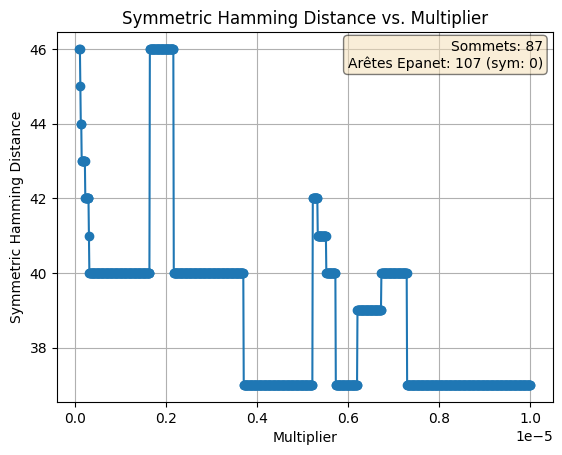

In [25]:
create_graph_hamming_mult('net3_1s.inp', multipliers_source, multipliers_destination)

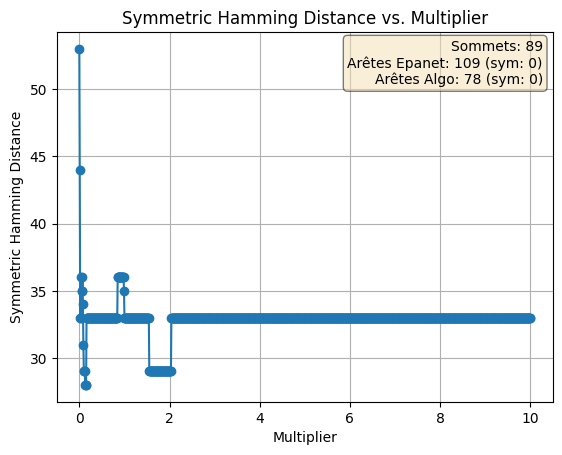

In [ ]:
create_graph_hamming_mult('net3_2s.inp', multipliers_source, multipliers_destination)

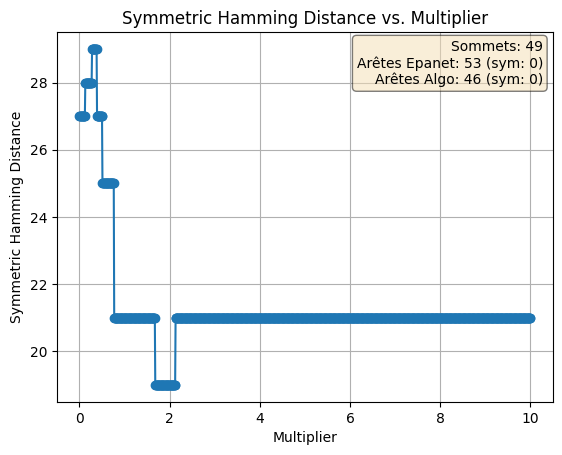

In [ ]:
create_graph_hamming_mult('generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination)

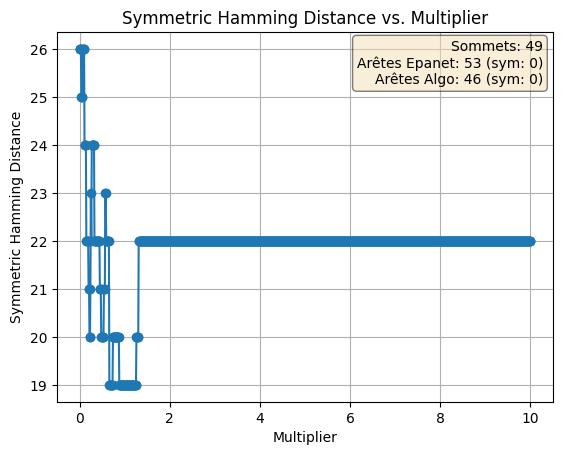

In [ ]:
create_graph_hamming_mult('generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination)

# COMPARAISON Hamming et efficacite

## demande fixe avec multiplicateur source somme ponderé

In [ ]:
color_by = 'source'

multipliers_source = np.linspace(0.01, 10.0, 1000)
multipliers_destination = np.array([1.0])


In [ ]:
def create_graph_hamming_eff(file_input, multipliers_source, multipliers_destination, color_by='source'):
    distances = []
    x = []
    colors = []

    for mult_source in multipliers_source:
        for mult_destination in multipliers_destination:
            commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {mult_destination} 1.0']
            resultat = subprocess.run(commande, capture_output=True, text=True)

            result, arcs, n, efficacite, sym_arcs = parser('output_epanet.txt')
            result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo = parser('output_algo.txt')

            dist = hamming_distance_symmetrique(result, result_algo)
            distances.append(dist)

            x.append(efficacite_algo)

            if color_by == 'source':
                colors.append(mult_source)
            else:
                colors.append(mult_destination)

    fig, ax = plt.subplots()
    sc = ax.scatter(x, distances, c=colors, cmap='viridis', s=10)
    ax.set_xlabel('Algorithm Efficiency')
    ax.set_ylabel('Symmetric Hamming Distance')
    ax.set_title('Symmetric Hamming Distance vs. Algorithm Efficiency')
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Source Multiplier' if color_by == 'source' else 'Destination Multiplier')


    ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs} (sym: {sym_arcs})\nArêtes Algo: {arcs_algo} (sym: {sym_arcs_algo})', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()


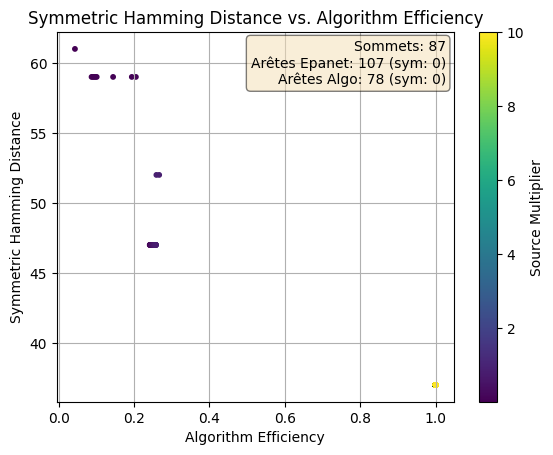

In [ ]:
create_graph_hamming_eff('net3_1s.inp', multipliers_source, multipliers_destination, color_by)

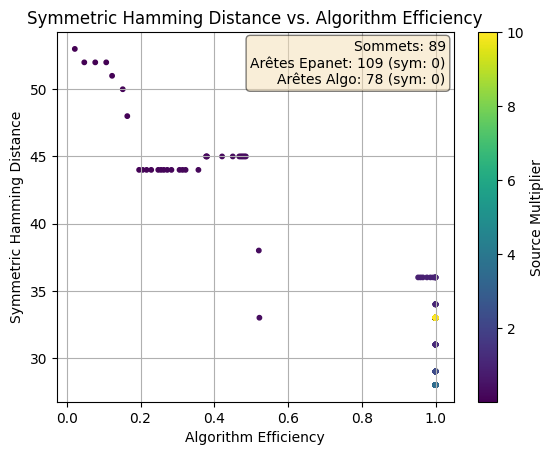

In [ ]:
create_graph_hamming_eff('net3_2s.inp', multipliers_source, multipliers_destination, color_by)

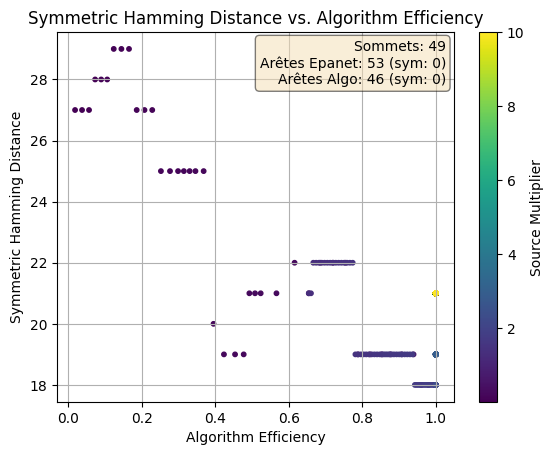

In [ ]:
create_graph_hamming_eff('generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, color_by)

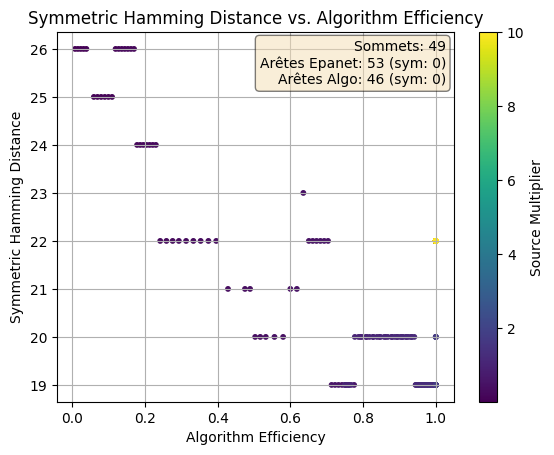

In [ ]:
create_graph_hamming_eff('generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, color_by)

# Efficacite EPA vs Efficacite FF